Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Object columns remaining: []


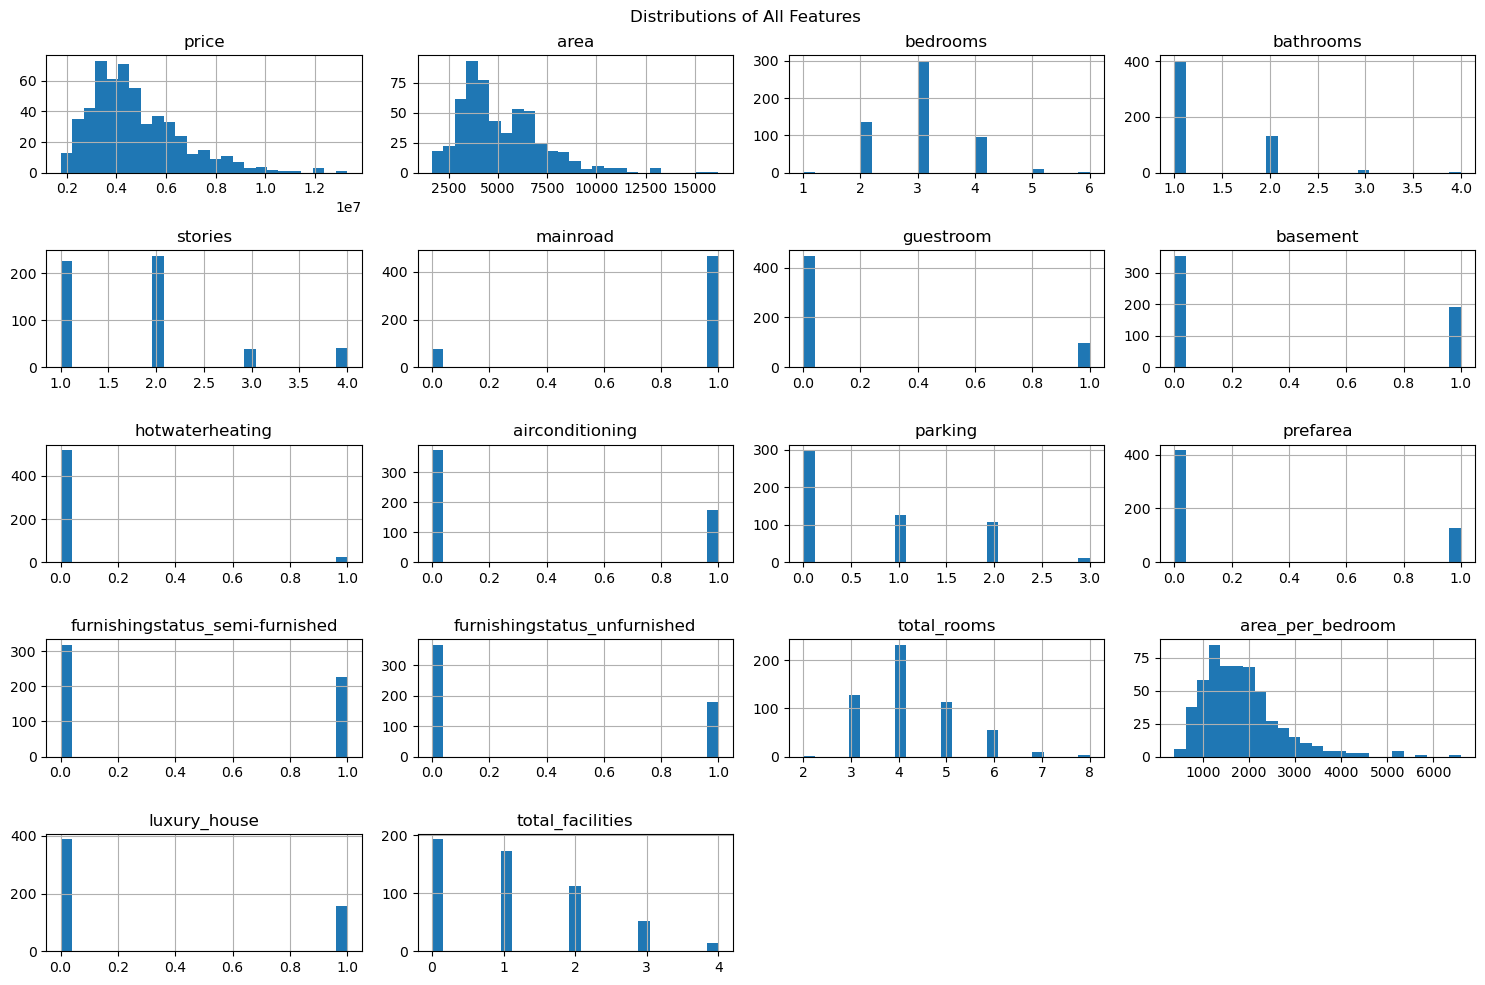

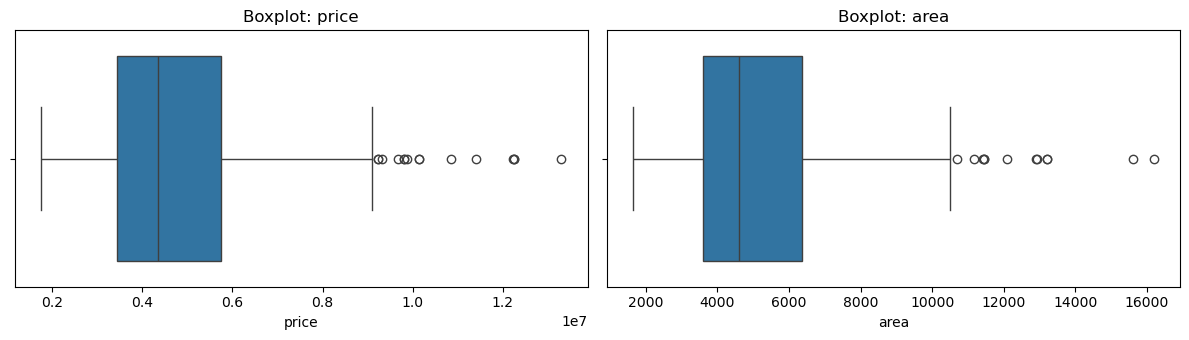


Correlation with price:
price                              1.000000
area                               0.535997
bathrooms                          0.517545
total_facilities                   0.513975
total_rooms                        0.511809
luxury_house                       0.487623
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
area_per_bedroom                   0.244809
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


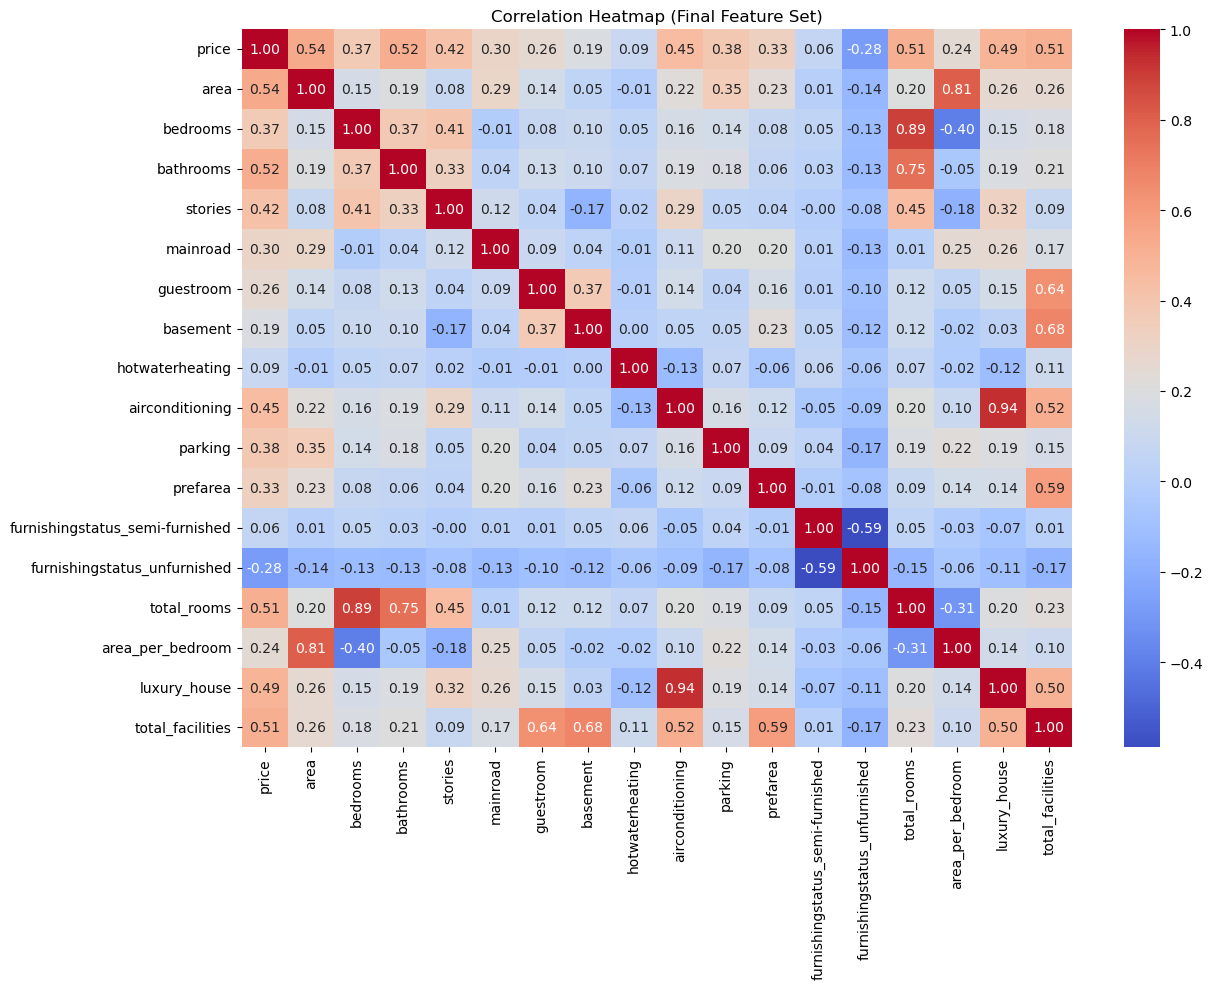

X_train: (436, 17) | X_test: (109, 17)
area: 11 train outliers clipped
area_per_bedroom: 16 train outliers clipped

Training 7 models...
  Linear Regression trained.
  Decision Tree trained.
  Random Forest trained.
  Gradient Boosting trained.
  XGBoost trained.
  LightGBM trained.
  CatBoost trained.

===== MODEL LEADERBOARD (by R2) =====


,Model,MAE,RMSE,R2 Score,MAPE
0,Linear Regression,9.722548e+05,1.347961e+06,0.640523,0.208717
1,Random Forest,1.032068e+06,1.404338e+06,0.609825,0.217092
2,Gradient Boosting,1.028448e+06,1.413981e+06,0.604448,0.217560
3,CatBoost,1.014281e+06,1.421590e+06,0.600180,0.212621
4,XGBoost,1.057916e+06,1.441732e+06,0.588770,0.223153
5,LightGBM,1.035737e+06,1.454299e+06,0.581570,0.213784
6,Decision Tree,1.227705e+06,1.595048e+06,0.496658,0.267901


Best model so far: Linear Regression (R2 = 0.641)

Tuning Random Forest (GridSearchCV, ~1-2 min)...
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Tuned RF test R2: 0.594


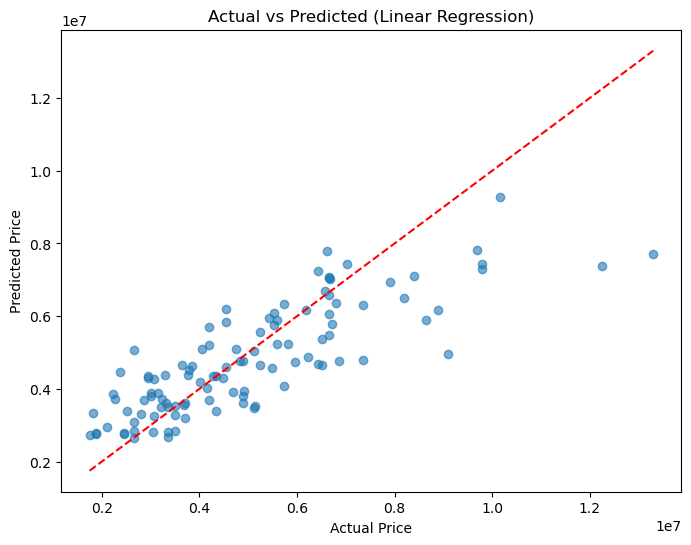


Saved: Linear Regression -> best_housing_model.pkl (+ scaler, feature_columns, clip_bounds)

  SERVER IS RUNNING with model: Linear Regression
  Paste these in your browser:

  Web form:
    http://localhost:5000

  Direct URL prediction (edit the numbers freely):
    http://localhost:5000/predict?area=6000&bedrooms=3&bathrooms=2&stories=2&parking=1&mainroad=yes&airconditioning=yes&furnishingstatus=furnished

  Tip: change any value in the URL and press Enter
       -> instant new prediction as JSON.
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [2]:
# ================================================================
# HOUSING PRICE PREDICTION - COMPLETE PIPELINE IN ONE JUPYTER CELL
# EDA + 7 MODELS + EVALUATION + TUNING + SAVE + WEB SERVER + URL API
# ----------------------------------------------------------------
# HOW TO USE:
#   1. Put Housing.csv next to your notebook
#   2. Paste this WHOLE block into ONE cell and run it
#   3. When it finishes, paste in your browser:
#        http://localhost:5000                     -> web form
#        http://localhost:5000/predict?area=6000   -> JSON result
# The server runs in a background thread - notebook stays usable.
# Re-running the cell? Restart the kernel first (port stays busy).
# ================================================================

# !pip install flask scikit-learn pandas seaborn joblib          # required
# !pip install xgboost lightgbm catboost                         # optional

import threading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from flask import Flask, request, jsonify, render_template_string
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,
                              GradientBoostingRegressor)
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
import warnings
warnings.filterwarnings("ignore")

# Optional boosting libraries - skipped automatically if missing
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except ImportError:
    HAS_CAT = False

BINARY_COLS = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

# Set False to skip GridSearchCV (saves ~1-2 minutes)
DO_TUNING = True

# ================================================================
# STEP 1 - LOAD DATA
# ================================================================
data = pd.read_csv("Housing.csv")
print("Shape:", data.shape)
display(data.head())

# ================================================================
# STEP 2 - ENCODING (explicit map, deterministic - no LabelEncoder)
# ================================================================
for col in BINARY_COLS:
    data[col] = data[col].map({'yes': 1, 'no': 0}).astype(int)

data = pd.get_dummies(data, columns=['furnishingstatus'],
                      drop_first=True, dtype=int)
print("Object columns remaining:",
      data.select_dtypes(include='object').columns.tolist())

# ================================================================
# STEP 3 - FEATURE ENGINEERING
# (one shared function: used for training AND every web request)
# ================================================================
def build_features(df):
    df = df.copy()
    df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
    df["area_per_bedroom"] = df["area"] / df["bedrooms"].replace(0, 1)
    df["luxury_house"] = ((df["airconditioning"] == 1) &
                          (df["mainroad"] == 1)).astype(int)
    df["total_facilities"] = (df["guestroom"] + df["basement"] +
                              df["hotwaterheating"] +
                              df["airconditioning"] + df["prefarea"])
    return df

data = build_features(data)

# ================================================================
# STEP 4 - EDA: distributions, boxplots, correlation heatmap
# ================================================================
data.hist(figsize=(15, 10), bins=25)
plt.suptitle("Distributions of All Features")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sns.boxplot(x=data["price"], ax=axes[0])
axes[0].set_title("Boxplot: price")
sns.boxplot(x=data["area"], ax=axes[1])
axes[1].set_title("Boxplot: area")
plt.tight_layout()
plt.show()

correlation = data.corr(numeric_only=True)
print("\nCorrelation with price:")
print(correlation["price"].sort_values(ascending=False))

plt.figure(figsize=(13, 10))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Final Feature Set)")
plt.tight_layout()
plt.show()

# ================================================================
# STEP 5 - SPLIT FIRST (leak-free!), then clip outliers with
# bounds learned on TRAIN only. Never clip y_test.
# ================================================================
X = data.drop("price", axis=1)
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

CLIP_BOUNDS = {}
for col in ['area', 'area_per_bedroom']:   # continuous columns only
    Q1, Q3 = X_train[col].quantile(0.25), X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    CLIP_BOUNDS[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    n_out = ((X_train[col] < CLIP_BOUNDS[col][0]) |
             (X_train[col] > CLIP_BOUNDS[col][1])).sum()
    print(f"{col}: {n_out} train outliers clipped")
    X_train[col] = X_train[col].clip(*CLIP_BOUNDS[col])
    X_test[col] = X_test[col].clip(*CLIP_BOUNDS[col])

# tame extreme targets in TRAIN ONLY (test target stays real)
q1y, q3y = y_train.quantile(0.25), y_train.quantile(0.75)
iqr_y = q3y - q1y
y_train = y_train.clip(q1y - 1.5 * iqr_y, q3y + 1.5 * iqr_y)

FEATURE_COLUMNS = list(X_train.columns)

# ================================================================
# STEP 6 - SCALING (fit on train only)
# ================================================================
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train),
                         columns=FEATURE_COLUMNS, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test),
                        columns=FEATURE_COLUMNS, index=X_test.index)

# ================================================================
# STEP 7 - TRAIN ALL MODELS
# ================================================================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100,
                                           random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}
if HAS_XGB:
    models["XGBoost"] = XGBRegressor(n_estimators=100,
                                     learning_rate=0.1,
                                     max_depth=5, random_state=42)
if HAS_LGBM:
    models["LightGBM"] = LGBMRegressor(random_state=42, verbose=-1)
if HAS_CAT:
    models["CatBoost"] = CatBoostRegressor(verbose=0, random_state=42)

print(f"\nTraining {len(models)} models...")
predictions = {}
for name, mdl in models.items():
    mdl.fit(X_train_s, y_train)
    predictions[name] = mdl.predict(X_test_s)
    print(f"  {name} trained.")

# ================================================================
# STEP 8 - EVALUATE ALL MODELS
# ================================================================
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2 Score": r2_score(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }

results = pd.DataFrame([evaluate_model(n, y_test, p)
                        for n, p in predictions.items()])
results_sorted = results.sort_values(
    "R2 Score", ascending=False).reset_index(drop=True)
print("\n===== MODEL LEADERBOARD (by R2) =====")
display(results_sorted)

best_row = results_sorted.iloc[0]
best_model_name = best_row["Model"]
best_model = models[best_model_name]
y_pred_best = predictions[best_model_name]
print(f"Best model so far: {best_model_name} "
      f"(R2 = {best_row['R2 Score']:.3f})")

# ================================================================
# STEP 9 - HYPERPARAMETER TUNING (Random Forest, compact grid)
# ================================================================
if DO_TUNING:
    print("\nTuning Random Forest (GridSearchCV, ~1-2 min)...")
    grid = GridSearchCV(
        RandomForestRegressor(random_state=42),
        {'n_estimators': [100, 200],
         'max_depth': [None, 10, 20],
         'min_samples_split': [2, 5],
         'min_samples_leaf': [1, 2]},
        cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_s, y_train)
    print("Best params:", grid.best_params_)

    tuned = grid.best_estimator_
    tuned_res = evaluate_model("Random Forest (Tuned)", y_test,
                               tuned.predict(X_test_s))
    print(f"Tuned RF test R2: {tuned_res['R2 Score']:.3f}")

    if tuned_res["R2 Score"] > best_row["R2 Score"]:
        print("-> Tuned RF wins, using it as the final model.")
        best_model = tuned
        best_model_name = "Random Forest (Tuned)"
        y_pred_best = tuned.predict(X_test_s)

# ================================================================
# STEP 10 - FINAL PLOTS: actual vs predicted + feature importance
# ================================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

if hasattr(best_model, "feature_importances_"):
    imp = pd.DataFrame({
        "Feature": FEATURE_COLUMNS,
        "Importance": best_model.feature_importances_,
    }).sort_values("Importance", ascending=False)
    imp.plot(x="Feature", y="Importance", kind="bar",
             figsize=(12, 5), legend=False)
    plt.title(f"Feature Importance ({best_model_name})")
    plt.tight_layout()
    plt.show()

# ================================================================
# STEP 11 - SAVE ARTIFACTS
# ================================================================
joblib.dump(best_model, "best_housing_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(FEATURE_COLUMNS, "feature_columns.pkl")
joblib.dump(CLIP_BOUNDS, "clip_bounds.pkl")
print(f"\nSaved: {best_model_name} -> best_housing_model.pkl "
      "(+ scaler, feature_columns, clip_bounds)")

model = best_model   # the web server below uses this

# ================================================================
# STEP 12 - WEB SERVER (background thread) + URL PREDICTION API
# ================================================================
PAGE = """
<!DOCTYPE html><html><head><title>Housing Predictor</title><style>
 body{font-family:Arial;background:#0f172a;color:#e2e8f0;display:flex;
      justify-content:center;padding:30px}
 .c{background:#1e293b;border-radius:14px;padding:26px;max-width:640px;width:100%}
 h2{color:#7dd3fc;margin:0 0 14px}
 .g{display:grid;grid-template-columns:1fr 1fr;gap:10px}
 label{font-size:11px;color:#94a3b8;text-transform:uppercase;
       display:block;margin-bottom:3px}
 input,select{width:100%;padding:8px;border-radius:8px;border:1px solid #334155;
       background:#0f172a;color:#e2e8f0;box-sizing:border-box}
 button{grid-column:1/-1;padding:12px;border:0;border-radius:10px;cursor:pointer;
       background:linear-gradient(90deg,#0ea5e9,#6366f1);color:#fff;
       font-weight:800;font-size:15px;margin-top:6px}
 #r{margin-top:16px;text-align:center;font-size:28px;font-weight:900;color:#34d399}
</style></head><body><div class="c">
<h2>🏠 Housing Price Predictor</h2>
<form id="f" class="g">
 <div><label>Area sq ft</label><input name="area" value="6000"></div>
 <div><label>Bedrooms</label><input name="bedrooms" value="3"></div>
 <div><label>Bathrooms</label><input name="bathrooms" value="2"></div>
 <div><label>Stories</label><input name="stories" value="2"></div>
 <div><label>Parking</label><input name="parking" value="1"></div>
 <div><label>Furnishing</label><select name="furnishingstatus">
   <option>furnished</option><option>semi-furnished</option>
   <option>unfurnished</option></select></div>
 <div><label>Main road</label><select name="mainroad">
   <option>yes</option><option>no</option></select></div>
 <div><label>Guest room</label><select name="guestroom">
   <option>no</option><option>yes</option></select></div>
 <div><label>Basement</label><select name="basement">
   <option>no</option><option>yes</option></select></div>
 <div><label>Hot water heat</label><select name="hotwaterheating">
   <option>no</option><option>yes</option></select></div>
 <div><label>Air conditioning</label><select name="airconditioning">
   <option>yes</option><option>no</option></select></div>
 <div><label>Preferred area</label><select name="prefarea">
   <option>no</option><option>yes</option></select></div>
 <button>Predict</button>
</form><div id="r"></div></div>
<script>
document.getElementById('f').onsubmit = async function(e){
  e.preventDefault();
  const q = new URLSearchParams(new FormData(this)).toString();
  const res = await fetch('/predict?' + q);
  const out = await res.json();
  document.getElementById('r').textContent =
    out.success ? out.formatted : ('Error: ' + out.error);
};
</script></body></html>
"""

app = Flask(__name__)

@app.route("/")
def home():
    return render_template_string(PAGE)

@app.route("/predict")           # GET -> works by pasting a URL!
def predict():
    try:
        g = request.args        # everything comes from the URL
        row = {
            "area": float(g.get("area", 6000)),
            "bedrooms": int(g.get("bedrooms", 3)),
            "bathrooms": int(g.get("bathrooms", 2)),
            "stories": int(g.get("stories", 2)),
            "parking": int(g.get("parking", 1)),
        }
        for f in BINARY_COLS:
            row[f] = 1 if str(g.get(f, "no")).lower() in (
                "1", "yes", "true") else 0
        status = g.get("furnishingstatus", "furnished")
        row["furnishingstatus_semi-furnished"] = int(
            status == "semi-furnished")
        row["furnishingstatus_unfurnished"] = int(
            status == "unfurnished")

        df = build_features(pd.DataFrame([row]))
        for col, (lo, hi) in CLIP_BOUNDS.items():
            df[col] = df[col].clip(lo, hi)
        df = df[FEATURE_COLUMNS]                 # exact column order
        price = float(model.predict(scaler.transform(df))[0])

        return jsonify({"success": True,
                        "model": best_model_name,
                        "predicted_price": round(price, 2),
                        "formatted": f"Rs {price:,.0f}"})
    except Exception as e:
        return jsonify({"success": False, "error": str(e)}), 400

def run_server():
    # use_reloader=False is REQUIRED inside Jupyter
    app.run(port=5000, debug=False, use_reloader=False)

threading.Thread(target=run_server, daemon=True).start()

print()
print("=" * 60)
print(f"  SERVER IS RUNNING with model: {best_model_name}")
print("  Paste these in your browser:")
print()
print("  Web form:")
print("    http://localhost:5000")
print()
print("  Direct URL prediction (edit the numbers freely):")
print("    http://localhost:5000/predict?area=6000&bedrooms=3"
      "&bathrooms=2&stories=2&parking=1&mainroad=yes"
      "&airconditioning=yes&furnishingstatus=furnished")
print()
print("  Tip: change any value in the URL and press Enter")
print("       -> instant new prediction as JSON.")
